In [2]:
import pandas as pd

In [3]:
from src import data_broker
from src import calendar_iterator
from src import strategy_selector_1
from src import filter_optimizer_1
from src import performance_evaluator_1,performance_evaluator

In [4]:
# params
initial_capital= 100000.0
transaction_cost_pct=.001

forward_month=6
allocation_type='equal'

In [5]:
# 1. Set up all components
broker = data_broker.DataBroker(tickers=["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL"], start_date="2022-01-01", end_date="2026-06-01")
universe_data = broker.fetch_universe_data()
is_data,oos_data=broker.split_train_test(universe_data,forward_month)




calendar = calendar_iterator.CalendarIterator(is_data, interval="ME")
strategy = strategy_selector_1.InformationDiscreteMomentum(lookback_days=252)
strategy2= strategy_selector_1.InformationDiscreteWithExhaustion(lookback_days=252)


portfolio_filter = filter_optimizer_1.VolumeWeightFilter(top_percent=0.40, min_dollar_volume=10_000_000, allocation_type=allocation_type)
evaluator = performance_evaluator.PerformanceEvaluator(initial_capital=initial_capital, transaction_cost_pct=transaction_cost_pct)


[*********************100%***********************]  5 of 5 completed


In [6]:
universe_data

{'price':                   AAPL        MSFT        NVDA        AMZN       GOOGL
 Date                                                                  
 2022-01-03  177.939713  322.462341   30.026142  170.404495  143.717133
 2022-01-04  175.681381  316.933136   29.197763  167.522003  143.130310
 2022-01-05  171.008255  304.766663   27.517075  164.356995  136.564026
 2022-01-06  168.153580  302.358490   28.089262  163.253998  136.536789
 2022-01-07  168.319794  302.512543   27.161192  162.554001  135.812714
 ...                ...         ...         ...         ...         ...
 2026-05-22  308.820007  418.570007  215.079330  266.320007  382.741394
 2026-05-26  308.329987  416.029999  214.609879  265.290009  388.647858
 2026-05-27  310.850006  412.670013  212.352509  271.850006  388.597870
 2026-05-28  312.510010  426.989990  214.000580  274.000000  389.897125
 2026-05-29  312.059998  450.239990  210.894211  270.640015  380.112946
 
 [1105 rows x 5 columns],
 'volume':                 

# 1 report at final

In [7]:
# 2. Execute Orchestrator Loop
for date in calendar.generate_rebalance_dates():
    snapshot = calendar.get_historical_snapshot(date)
    
    # Run pipeline
    scores = strategy.calculate_scores(snapshot)
    target_weights = portfolio_filter.generate_weights(scores, snapshot)
    
    # Update performance
    evaluator.update_portfolio_state(date, target_weights, universe_data["price"])

In [24]:
df_nav.index.max()

Timestamp('2026-05-29 00:00:00')

In [25]:
# 3. Get Report
report = evaluator.generate_report(forward_months=forward_month)

In [27]:
report

{'In-Sample Performance': {'Total Return': np.float64(1.3238000945477655),
  'Max Drawdown': np.float64(-0.35261623010957427),
  'Final Value': np.float64(232147.62944532177)},
 'Forward Performance (OOS)': {'Total Return': np.float64(0.17652986073458865),
  'Max Drawdown': np.float64(-0.0878778192843477),
  'Final Value': np.float64(280776.9261305036)}}

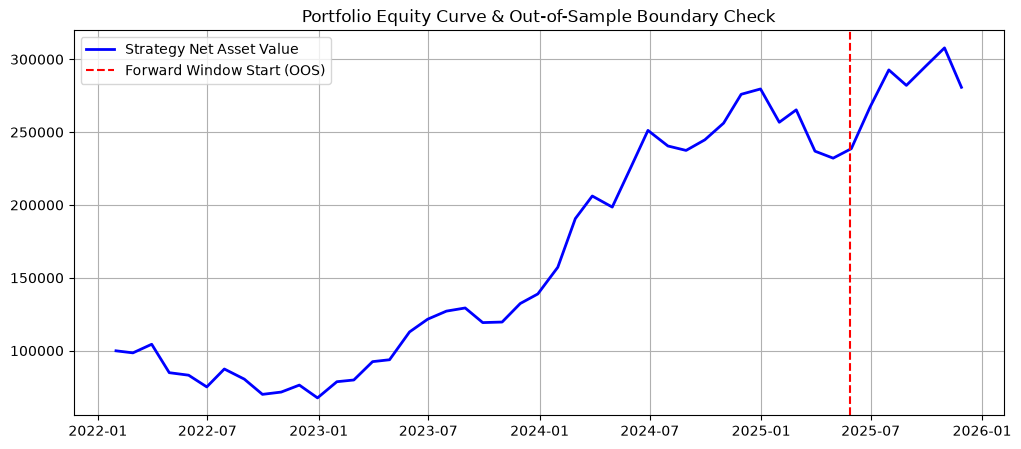

{
    "In-Sample Performance": {
        "Total Return": 1.3238000945477655,
        "Max Drawdown": -0.35261623010957427,
        "Final Value": 232147.62944532177
    },
    "Forward Performance (OOS)": {
        "Total Return": 0.17652986073458865,
        "Max Drawdown": -0.0878778192843477,
        "Final Value": 280776.9261305036
    }
}


In [26]:
# 4 visualize and inspect 
import matplotlib.pyplot as plt

# Pull raw history dataframe out of evaluator for manual data checking
df_nav = pd.DataFrame(evaluator.nav_history).set_index("date")

plt.figure(figsize=(12, 5))
plt.plot(df_nav['nav'], label='Strategy Net Asset Value', color='blue', lw=2)
plt.axvline(x=df_nav.index[-1] - pd.DateOffset(months=6), color='red', linestyle='--', label='Forward Window Start (OOS)')
plt.title("Portfolio Equity Curve & Out-of-Sample Boundary Check")
plt.legend()
plt.grid(True)
plt.show()

# Print out metrics
import json
print(json.dumps(report, indent=4))

# daily tracking

In [33]:
from importlib import reload

In [31]:
reload(strategy_selector_1)

<module 'src.strategy_selector_1' from '/Users/zhigangyu/Documents/Project Z/src/strategy_selector_1.py'>

In [7]:
# In your Jupyter notebook / main executor:
evaluator_1 = performance_evaluator_1.AdvancedEvaluator(initial_capital=100000.0, execution_lag=1)
rebalance_dates = calendar.generate_rebalance_dates()

active_rebalance_date = rebalance_dates[0]

In [8]:
# Loop through every single daily date index in your data matrix
for today in universe_data["price"].index:
    
    # 1. Update and track the portfolio's actual value today
    evaluator_1.log_daily_value(today, universe_data["price"], active_rebalance_date)
    
    # 2. Check if today is a scheduled rebalance day
    if today in rebalance_dates:
        snapshot = calendar.get_historical_snapshot(today)
        scores = strategy.calculate_scores(snapshot)
        target_weights = portfolio_filter.generate_weights(scores, snapshot)
        
        # Fire rebalance execution (which safely occurs at T + execution_lag)
        evaluator_1.execute_rebalance(today, target_weights, universe_data["price"])
        active_rebalance_date = today

        

In [32]:
target_weights

AAPL     0.0
MSFT     0.0
NVDA     0.5
AMZN     0.0
GOOGL    0.5
dtype: float64

In [9]:
# 3. Get Report
report = evaluator_1.generate_advanced_report(forward_months=6)

In [25]:
evaluator_1.daily_nav.name='nav'
evaluator_1.daily_nav.index=evaluator_1.daily_nav.index.rename('date')

In [26]:
df_nav=pd.DataFrame(evaluator_1.daily_nav)

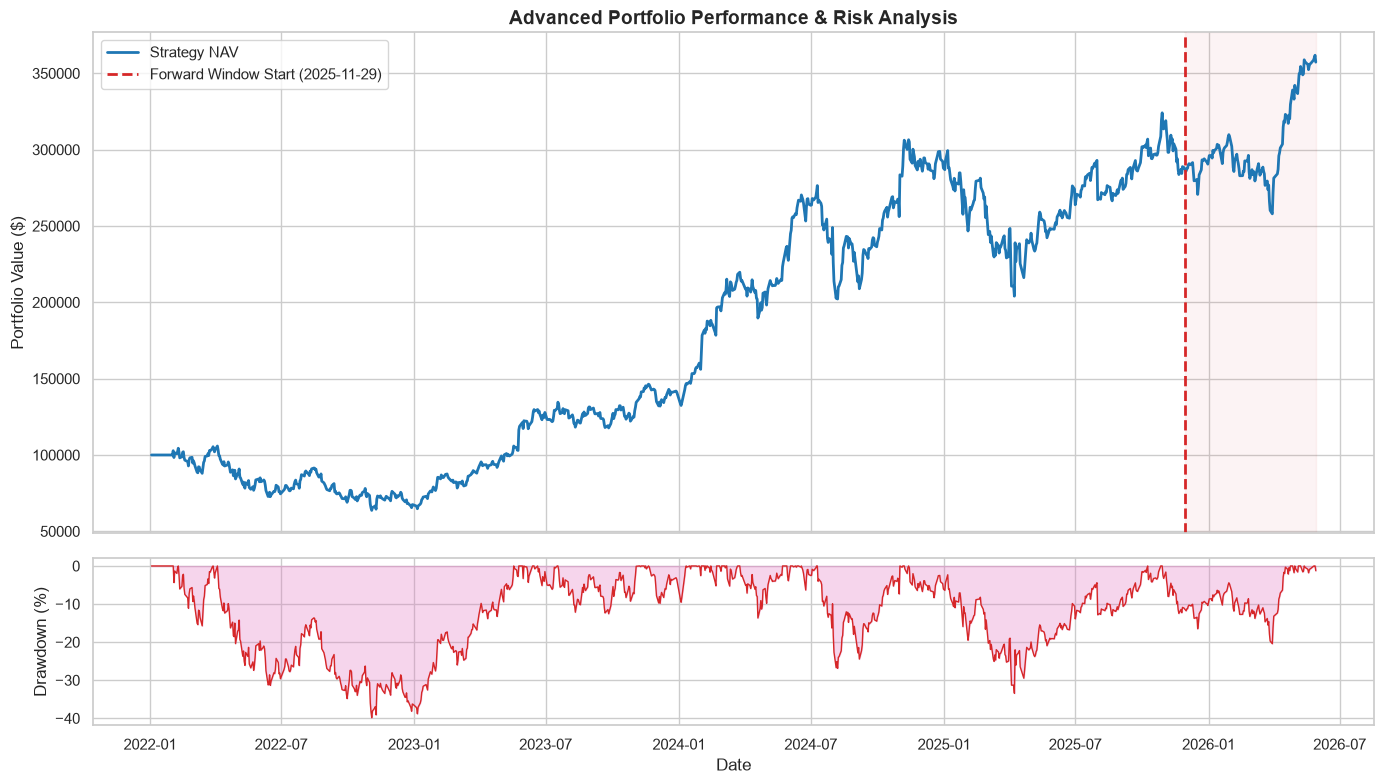

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for a clean, professional look
sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Plot 1: Net Asset Value ---
ax1.plot(df_nav.index, df_nav['nav'], color='#1f77b4', lw=2, label='Strategy NAV')

# Mark the Out-of-Sample (Forward Performance) Boundary
cutoff_date = df_nav.index[-1] - pd.DateOffset(months=6) # matching your N_months
ax1.axvline(x=cutoff_date, color='#d62728', linestyle='--', lw=2, 
            label=f'Forward Window Start ({cutoff_date.strftime("%Y-%m-%d")})')

# Visual shading for the Forward Performance Window
ax1.axvspan(cutoff_date, df_nav.index[-1], color='#d62728', alpha=0.05)

ax1.set_title('Advanced Portfolio Performance & Risk Analysis', fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.legend(loc='upper left', fontsize=11)

# --- Plot 2: Underwater Drawdown ---
rolling_max = df_nav['nav'].cummax()
drawdown = (df_nav['nav'] - rolling_max) / rolling_max

ax2.fill_between(drawdown.index, drawdown * 100, 0, color='#e377c2', alpha=0.3)
ax2.plot(drawdown.index, drawdown * 100, color='#d62728', lw=1)
ax2.set_ylabel('Drawdown (%)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)

plt.tight_layout()
plt.show()

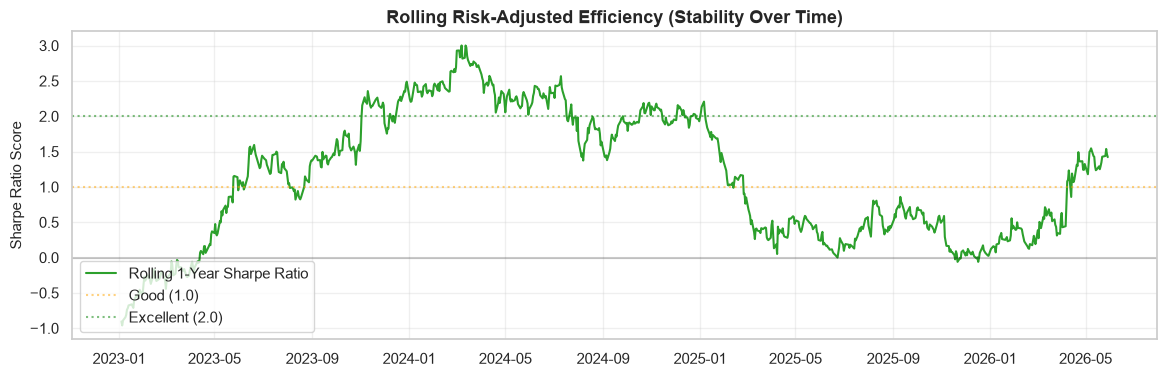

In [28]:
# Calculate rolling 252-day annualized volatility and returns
daily_returns = df_nav['nav'].pct_change()
rolling_ann_return = daily_returns.rolling(252).mean() * 252
rolling_ann_vol = daily_returns.rolling(252).std() * (252**0.5)

# Calculate Rolling Sharpe (assuming a constant 4% risk-free rate for simplicity)
rolling_sharpe = (rolling_ann_return - 0.04) / rolling_ann_vol

plt.figure(figsize=(14, 4))
plt.plot(rolling_sharpe.index, rolling_sharpe, color='#2ca02c', lw=1.5, label='Rolling 1-Year Sharpe Ratio')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.2)
plt.axhline(y=1.0, color='orange', linestyle=':', alpha=0.5, label='Good (1.0)')
plt.axhline(y=2.0, color='green', linestyle=':', alpha=0.5, label='Excellent (2.0)')

plt.title('Rolling Risk-Adjusted Efficiency (Stability Over Time)', fontsize=13, fontweight='bold')
plt.ylabel('Sharpe Ratio Score', fontsize=11)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
report

{'In-Sample': {'IS_Annualized_Return': np.float64(31.26),
  'IS_Annualized_Vol': np.float64(37.88),
  'IS_Sharpe_Ratio': np.float64(0.72),
  'IS_Sortino_Ratio': np.float64(1.09),
  'IS_Max_Drawdown': np.float64(-39.84)},
 'Forward_OOS': {'OOS_Annualized_Return': np.float64(57.27),
  'OOS_Annualized_Vol': np.float64(25.23),
  'OOS_Sharpe_Ratio': np.float64(2.11),
  'OOS_Sortino_Ratio': np.float64(3.44),
  'OOS_Max_Drawdown': np.float64(-16.74)}}

In [36]:
# Create an easy-to-read evaluation summary table
import pandas as pd

metrics_data = {
    "Metric Profile": ["Annualized Return", "Annualized Volatility", "Sharpe Ratio", "Sortino Ratio", "Max Drawdown"],
    "In-Sample (Historical)": [f"{report['In-Sample']['IS_Annualized_Return']}%", 
                                f"{report['In-Sample']['IS_Annualized_Vol']}%", 
                                report['In-Sample']['IS_Sharpe_Ratio'], 
                                report['In-Sample']['IS_Sortino_Ratio'], 
                                f"{report['In-Sample']['IS_Max_Drawdown']}%"],
    "Forward Performance (OOS)": [f"{report['Forward_OOS']['OOS_Annualized_Return']}%", 
                                   f"{report['Forward_OOS']['OOS_Annualized_Vol']}%", 
                                   report['Forward_OOS']['OOS_Sharpe_Ratio'], 
                                   report['Forward_OOS']['OOS_Sortino_Ratio'], 
                                   f"{report['Forward_OOS']['OOS_Max_Drawdown']}%"]
}

df_metrics = pd.DataFrame(metrics_data).set_index("Metric Profile")
display(df_metrics.style.set_properties(**{'text-align': 'center'})
                        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))

,In-Sample (Historical),Forward Performance (OOS)
Metric Profile,,
Annualized Return,31.26%,57.27%
Annualized Volatility,37.88%,25.23%
Sharpe Ratio,0.720000,2.110000
Sortino Ratio,1.090000,3.440000
Max Drawdown,-39.84%,-16.74%


# compare penalized with vol

In [ ]:
# In your Jupyter notebook / main executor:
evaluator_1 = performance_evaluator_1.AdvancedEvaluator(initial_capital=100000.0, execution_lag=1)
rebalance_dates = calendar.generate_rebalance_dates()

In [35]:
def run(universe_data,rebalance_dates, calendar,strategy,portfolio_filter,evaluator):
    active_rebalance_date = rebalance_dates[0]
    # Loop through every single daily date index in your data matrix
    for today in universe_data["price"].index:
        
        # 1. Update and track the portfolio's actual value today
        evaluator.log_daily_value(today, universe_data["price"], active_rebalance_date)
        
        # 2. Check if today is a scheduled rebalance day
        if today in rebalance_dates:
            snapshot = calendar.get_historical_snapshot(today)
            scores = strategy.calculate_scores(snapshot)
            target_weights = portfolio_filter.generate_weights(scores, snapshot)
            
            # Fire rebalance execution (which safely occurs at T + execution_lag)
            evaluator.execute_rebalance(today, target_weights, universe_data["price"])
            active_rebalance_date = today

    # 3. Get Report
    report = evaluator.generate_advanced_report(forward_months=6)
    return evaluator,report